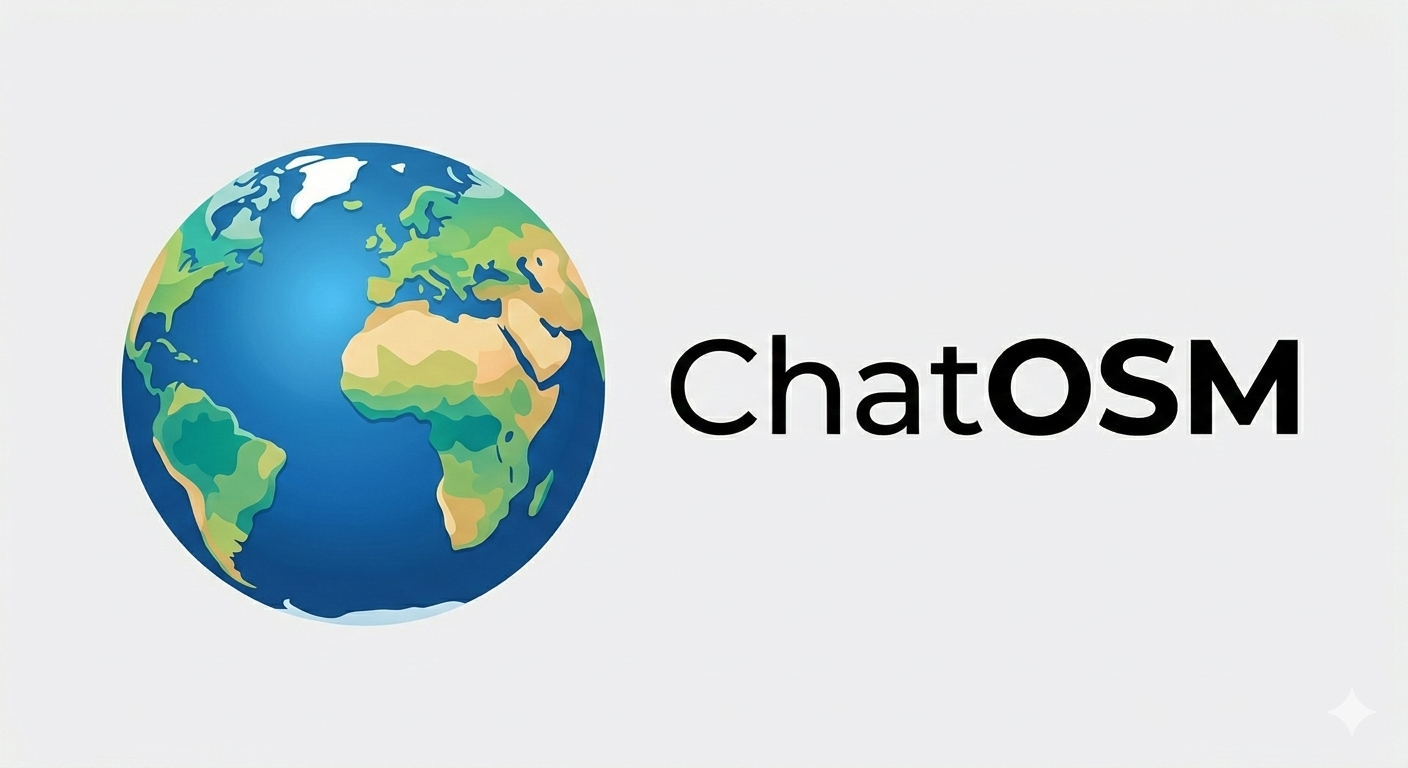

# ChatOSM

## 1. Introduction

[OpenStreetMap](https://wiki.openstreetmap.org/) is a project that creates and distributes free geographic data for the world. One of the ways to access the OSM map data is by the [Overpass API](https://wiki.openstreetmap.org/wiki/Overpass_API), which is read only. Overpass uses a specialized query language to query the vast amounts of data. Queries can be tested online on sites like [Overpass Turbo](https://overpass-turbo.eu/). For most users, accessing OSM data is not trivial, and requires good knowledge on their query language or in spatial data. ChatOSM tries to bridge that gap and make OSM data more accessible to the broader audience, by creating a chat-like interface where natural language prompts are turned into OSM queries and interactive maps.

## 2. Methodology

### 2.1 Loading the LLM

The new advancements in Artificial Intelligence (AI), and in specific, Natural Language Processing (NLP), have enabled advancements in many fields, including Geocomputing. In this project, a 8B parameter LLM accissible in [HuggingFace] for free (https://huggingface.co/) called [Hermes](https://huggingface.co/NousResearch/Hermes-3-Llama-3.1-8B) is used in an agentic system. This model was finetuned from a Llama 3.1 model to specialize in tool calling. Tool calling enables large language models to interact with external systems, APIs, and databases to perform actions or fetch real-time data, bypassing their training data limitations. Developers provide the LLM with a list of available tools and their descriptions. When asked a question, the LLM analyzes the request and, if necessary, responds with a structured JSON object recommending a tool call rather than a conversational answer. In the code below, the pretrained model parameters are loaded into the workspace from HuggingFace. Note that this requires considerable disk space and computational power, I'm using the A100 GPU on Colab PRO.

In [ ]:
from huggingface_hub import login
from google.colab import userdata

key = userdata.get('HUGGINGFACE_TOKEN')
login(key)

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

checkpoint = "NousResearch/Hermes-2-Pro-Llama-3-8B"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForCausalLM.from_pretrained(checkpoint, dtype="auto", device_map="auto")

## 2.2 Creating Tools for the LLM

Now that the model is loaded, the next step is to create the tools that the LLM can call during a conversation.

- The first tool, `search_places_in_area`, is designed to search OpenStreetMap (OSM) for places within an administrative area. OSM uses a tagging system based on *key=value* pairs to describe geographic features, where the key defines a category (e.g., `highway`) and the value specifies a particular type (e.g., `motorway`). This tool searches for places whose tags match the provided key–value filters.  

  The function accepts two main arguments: `area_name`, a string representing the geographic area of interest, and `filters`, a list of dictionaries containing key–value pairs used to filter OSM features. These inputs are generated by the agent based on the user’s prompt. The function constructs an Overpass API query using these parameters, retrieves the matching data, and returns the resulting elements.

- The second tool, `search_places_in_radius`, operates similarly but performs a proximity-based search instead of searching within a predefined administrative boundary. It includes an additional argument, `radius`, which specifies the search distance in meters from the given location. If the radius is provided in another unit (for example, miles or kilometers), the agent is expected to convert it into meters before calling the tool.

Both tools rely on four auxiliary functions. The functions `get_location` (used by `search_places_in_radius`) and `get_bbox_from_location` (used by `search_places_in_area`) interact with the [Nominatim API](https://nominatim.org/) to convert location names into geographic coordinates, either a center point for radius searches or a bounding box for area-based searches. Although the Overpass query language supports searching directly by location names, using Nominatim proved more reliable in practice because it does not depend on exact name matches. The `execute_overpass` function is used to create the Overpass query and call it in a reusable way. Finally, `simplify_osm` processes the raw Overpass response to clean and standardize the output by extracting the relevant elements and their associated metadata.

In [ ]:
# AUXILIAR FUNCTIONS

import requests

def get_location(location_name):
    """Get the center coordinates of a location using the Nominatim API."""
    url = "https://nominatim.openstreetmap.org/search"
    params = {
        "q": location_name,
        "format": "json",
        "limit": 1
    }
    headers = {"User-Agent": "ChatOSM-App/1.0"}

    response = requests.get(url, params=params, headers=headers)
    data = response.json()

    if data:
        lat = float(data[0]["lat"])
        lon = float(data[0]["lon"])

        return lat, lon

    return None


def get_bbox_from_location(location_name):
    """Get the bounding box of a location using the Nominatim API."""
    url = "https://nominatim.openstreetmap.org/search"
    params = {
        "q": location_name,
        "format": "json",
        "limit": 1,
        "addressdetails": 0
    }

    headers = {
        "User-Agent": "OSM-Agent/1.0"
    }

    response = requests.get(url, params=params, headers=headers)
    response.raise_for_status()

    data = response.json()
    if not data:
        return None

    bbox = data[0]["boundingbox"]
    min_lat = float(bbox[0])
    max_lat = float(bbox[1])
    min_lon = float(bbox[2])
    max_lon = float(bbox[3])

    return min_lat, min_lon, max_lat, max_lon

from typing import List, Dict
import requests

def simplify_osm(elements):
    results = []

    for el in elements:
        tags = el.get("tags", {})

        lat = el.get("lat")
        lon = el.get("lon")

        if not lat and "center" in el:
            lat = el["center"]["lat"]
            lon = el["center"]["lon"]

        results.append({
            "id": el["id"],
            "name": tags.get("name"),
            "lat": lat,
            "lon": lon,
            "tags": tags
        })

    return results

def execute_overpass(search_region, filters):
    """Execute an Overpass query and return simplified results."""

    key_values = "".join(
        f'["{f["key"]}"="{f["value"]}"]'
        for f in filters
    )

    query = f"""
        [out:json][timeout:180];
        nwr{key_values}({search_region});
        out center;
    """

    print(query)

    response = requests.post("https://overpass-api.de/api/interpreter", data=query)
    response.raise_for_status()

    data = response.json()
    return simplify_osm(data["elements"])

Tool #1

In [ ]:
def search_places_in_area(area_name: str, filters: List[Dict[str, str]]):
    """
    Uses Nominatim to compute bounding box of the area name.
    Searches OpenStreetMap for places inside an administrative area.
    Creates a map with the places found by Overpass.

    Args:
        area_name: City or region name
        filters: List of OSM tag filters: [{"key": "", "value": ""}]

    Returns:
        List of places.
    """

    # Get bounding box from Nominatim
    min_lat, min_lon, max_lat, max_lon = get_bbox_from_location(area_name)
    search_region = f"{min_lat},{min_lon},{max_lat},{max_lon}"

    return execute_overpass(search_region, filters)

Tool #2

In [ ]:
def search_places_in_radius(area_name: str, radius: int, filters: List[Dict[str, str]]):
    """
    Uses Nominatim to compute center coordinates of the area name.
    Search OpenStreetMap for places within a radius of a location.
    Creates a map with the places found by Overpass.

    Args:
        area_name: Center location name
        radius: Search radius in meters
        filters: List of OSM tag filters: [{"key": "", "value": ""}]

    Returns:
        Simplified list of places.
    """

    if radius <= 0:
        raise ValueError("radius must be a positive integer")

    # Get center coordinates
    lat, lon = get_location(area_name)
    search_region = f"around:{radius},{lat},{lon}"

    return execute_overpass(search_region, filters)

All the tool function used by the agent have a multiline string defining the function, inputs, and outputs. Using `get_json_schema`, this schema can be automatically extracted. Then, a list of schemas is built to pass into the model so it's aware of what tools it has access to.

In [ ]:
from transformers.utils import get_json_schema

TOOLS = {
    "search_places_in_area": search_places_in_area,
    "search_places_in_radius": search_places_in_radius
}
tool_schemas = [
    get_json_schema(search_places_in_area),
    get_json_schema(search_places_in_radius)
]

### 2.3 Giving context to the agent

When making an agent, it's important to add a system message or context explaining their goal or how they should behave. In the code below, `system_message` is created which defines several rules the agent must follow. Furthermore, `OSM_TAGS` is provided to the agent as well, which is a dictionary of possible key-value pairs it can use as filters. This helps with reliability by avoiding unsuccessful queries from using non-valid key-value options.

In [ ]:
OSM_TAGS = {
    "amenity": [
        "restaurant", "cafe", "bar", "pub", "fast_food",
        "school", "hospital", "clinic", "library", "bank",
        "atm", "police", "parking", "theatre", "cinema",
        "place_of_worship"
    ],
    "shop": [
        "supermarket", "bakery", "convenience", "clothes",
        "electronics", "hairdresser", "books", "furniture"
    ],
    "cuisine": [
        "pizza", "burger", "sushi", "thai", "italian", "indian",
        "mexican", "chinese", "coffee", "vegetarian", "vegan"
    ],
    "aeroway": [
        "helipad", "runway"
    ],
    "railway": [
        "station", "subway_entrance", "tram_stop"
    ],
    "highway": [
        "bus_stop", "crossing"
    ],
    "tourism": [
        "museum", "attraction", "hotel", "viewpoint", "zoo", "gallery"
    ],
    "natural": [
        "water", "tree", "beach", "wood", "peak"
    ],
    "leisure": [
        "park", "pitch", "playground", "fitness_centre", "stadium", "swimming_pool"
    ],
    "landuse": [
        "commercial", "industrial", "retail", "residential", "forest"
    ],
    "craft": [
        "brewery", "winery"
    ],
    "building": [
        "yes", "residential", "commercial", "industrial", "retail"
    ],
    "office": [
        "company", "government", "NGO"
    ],
    "emergency": [
        "fire_station", "ambulance_station", "police"
    ],
    "historic": [
        "monument", "castle", "ruins", "memorial"
    ]
}

system_message = f"""
  You are an ChatOSM, an agent that helps users explore OpenStreetMap data.

  Rules:
  - Call only valid functions if necessary.
  - Use valid OSM key value pairs from {OSM_TAGS}.
  - If multiple conditions exist, include multiple filters.
"""

### 2.4 Creating the chat loop

The agent is provided with the chat history as the `messages` list which contains an ordered list of dictionaries that have information on who said what and the content of the conversation. In this project, tool calls will also be stored in the this list. `history` is a similar list but is used to visualize the chat, which requires a different format. Only the last 10 message exchanges are provided to the agent in order to not make the context window too large. However, the first message is always the system message defined above. In the chat history, some elements are not text, for example maps, which we don't add to `messages` because it isn't supported.

In [ ]:
def build_messages(history):
    """
    Construct a list of message for the agent from the chat history.
    """
    messages = [{"role": "system", "content": system_message}]

    if not history:
        return messages

    for msg in history[-10:]: # only keep latest 10 messages

        if not isinstance(msg, dict):
            continue

        role = msg.get("role")
        content = msg.get("content")

        if not isinstance(content, str):
            continue

        if "<iframe" in content or "folium-map" in content:
            continue

        messages.append({"role": role, "content": content})

    return messages

The function `generate_llm` produces a response from the LLM using the conversation history provided as a list of messages. The first step is tokenization. Tokenization is the process of breaking raw text into smaller units called tokens which may represent words, subwords, or characters, and converting them into numerical identifiers. This transformation allows the model to process language as mathematical data. During this stage, the model also receives the schemas of any tools it is allowed to call. Next, the model generates an output. LLMs operate in an autoregressive manner, meaning they predict one token at a time. Using a transformer-based neural network architecture, the model evaluates the input prompt together with all previously generated tokens to determine the most probable next token. This prediction loop continues until a stopping condition is reached or a maximum length is met. In this example, the generated response is limited to 256 tokens. Because the model’s output is initially represented as token IDs, a decoding step converts these tokens back into natural language text. Finally, the function returns the decoded, human-readable response.

In [ ]:
def generate_llm(messages):
    """
    Generate a response from the LLM.
    """
    inputs = tokenizer.apply_chat_template(
        messages,
        tools=tool_schemas,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    output = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

    text = tokenizer.decode(
        output[0][len(inputs["input_ids"][0]):],
        skip_special_tokens=True
    )

    return text

ChatOSM, unlike conventional AI chatbots, is capable of creating maps for the data gathered from the tool calls. The `build_map` function creates a map using the [folium](https://python-visualization.github.io/folium/latest/) library. The function first finds a good bouding box to display the data, then, for each result, it creates a marker with a popup that displays the location's name and metadata. Finally, the embeddable HTML map is returned.

In [ ]:
import folium
from folium.plugins import MarkerCluster

def build_map(result):
    """
    Build a map from the result of a tool call.
    """

    if not result:
        return "<p>No results found.</p>"

    lats = [float(r["lat"]) for r in result]
    lons = [float(r["lon"]) for r in result]

    padding = 0.01

    bounds = [
        (min(lats) - padding, min(lons) - padding),
        (max(lats) + padding, max(lons) + padding)
    ]

    m = folium.Map(tiles="CartoDB Voyager")

    m.fit_bounds(bounds)

    cluster = MarkerCluster().add_to(m)

    for r in result:
        lat = float(r["lat"])
        lon = float(r["lon"])
        tags = r.get("tags", {})

        name = tags.get("name", "Unnamed")

        popup_html = f"<b>{name}</b><br><br>"
        for k, v in tags.items():
            popup_html += f"<b>{k}:</b> {v}<br>"

        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            color="red",
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(popup_html, max_width=300),
        ).add_to(cluster)

    return m._repr_html_()

Finally, all the steps above can be combined to create a chat loop, where the user types a prompt and the agent responds, and possibly calls a tool. `osm_chatbot` is in charge of completing one of those loops with the receives new user message and chat history following these steps:
1. Construct the messages list to feed into the agent from the chat.
2. The agent generates a response.
3. Check if the agent called any tools in the response. Hermes does tool calls by writing a json between the special characters `<tool_call></tool_call>`. The json contains the tool name as well as the arguments to pass into the function.
4. If no tool calls detected, the function returns the models response. However, if a tool call was detected, then it tries to execute it with the arguments. Some safety measures are done with exceptions if something goes wrong.
5. The tool call and its output are passed into the agents context.
6. A map is created with the Overpass API results.
7. The agent generates an output for the second time, this time it comments on the tool result and summarizes it.
8. The function returns the map as well as the explanation.

In [ ]:
import re
import json

def osm_chatbot(user_message, history):

    history = history or []

    # Build messages
    messages = build_messages(history)
    messages.append({"role": "user", "content": user_message})

    # Agent response
    llm_text = generate_llm(messages)

    # Check if the agent called a tool
    match = re.search(r"<tool_call>(.*?)</tool_call>", llm_text, re.S)

    # Normal reply (no tool)
    if not match:
        return llm_text

    # Execute tool safely
    try:
        tool_call = json.loads(match.group(1))
        tool_name = tool_call["name"]
        arguments = tool_call.get("arguments", {})
    except Exception:
        return llm_text

    try:
        result = TOOLS[tool_name](**arguments)
    except Exception as e:
        return f"Something went wrong while processing your request, try again or ask something different."

    if not result:
        return f"No results were found. Try asking something different."

    # Add tool result to LLM context
    messages.append({"role": "tool", "name": tool_name, "content": json.dumps(result)})

    # Build map with the results
    map_html = build_map(result)

    # Second pass (explanation)
    final_text = generate_llm(messages)

    # Return map and text output
    return [
        {"role": "assistant", "content": final_text},
        {"role": "assistant", "content": gr.HTML(map_html)}
    ]

Finally, `osm_chatbot` can be called iteratively to form a conversational chatbot specialized in OSM data. The [Gradio](https://www.gradio.app/) library is used to create the chat and the user interface. Gradio is an open-source Python package that allows you to build web application with prebuilt frontent components focused on machine learning applications.

In [ ]:
import gradio as gr

# Initialize chat
chat_interface = gr.ChatInterface(
    fn=osm_chatbot,
    type="messages"
)

# Launch chat
chat_interface.launch(debug=True)

Main issues:
- Relative small model, interesting to use larger commercial LLM like GPT-5 or Claude. Hermes is small and prone to alucinate with so much text, but does quite well.
- Main issue is non valid key value filters.